# Data Preprocessing Reference Notebook

This notebook combines short theory explanations with reference code based on your format. The goal is to keep the same flow while fixing syntax and making the steps practical for real datasets.

## 1) Reading Data

In preprocessing, the first step is loading the dataset and quickly inspecting it. We usually check the full table, preview top and bottom rows, remove or handle missing values, slice rows and columns using `iloc`, and view summary statistics with `describe()`.

In [18]:
import pandas as pd

dataset = pd.read_csv('./data.csv')

# Full data preview
dataset

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,Pakistan,77.0,120000.0,Yes


In [3]:
# Top rows
dataset.head()

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes


In [4]:
# Bottom rows
dataset.tail()

,Country,Age,Salary,Purchased
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,Pakistan,77.0,120000.0,Yes


In [5]:
# Drop all rows with NaN (reference style)
dataset_no_nan = dataset.dropna()
dataset_no_nan

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
5,France,35.0,58000.0,Yes
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,Pakistan,77.0,120000.0,Yes


In [6]:
# iloc reference form:
# dataset.iloc[start_row:end_row, start_col:end_col]

# Example slice
dataset.iloc[0:5, 0:3]

,Country,Age,Salary
0,France,44.0,72000.0
1,Spain,27.0,48000.0
2,Germany,30.0,54000.0
3,Spain,38.0,61000.0
4,Germany,40.0,NaN


In [7]:
# All rows, all columns except last
dataset.iloc[:, :-1]

,Country,Age,Salary
0,France,44.0,72000.0
1,Spain,27.0,48000.0
2,Germany,30.0,54000.0
3,Spain,38.0,61000.0
4,Germany,40.0,NaN
5,France,35.0,58000.0
6,Spain,NaN,52000.0
7,France,48.0,79000.0
8,Germany,50.0,83000.0
9,Pakistan,77.0,120000.0


In [8]:
# Statistical summary
dataset.describe(include='all')

,Country,Age,Salary,Purchased
count,10,9.000000,9.000000,10
unique,4,NaN,NaN,2
top,France,NaN,NaN,No
freq,3,NaN,NaN,5
mean,NaN,43.222222,69666.666667,NaN
std,NaN,14.805217,22477.766793,NaN
min,NaN,27.000000,48000.000000,NaN
25%,NaN,35.000000,54000.000000,NaN
50%,NaN,40.000000,61000.000000,NaN
75%,NaN,48.000000,79000.000000,NaN


## 2) Plotting

Visualization helps detect spread, skewness, and outliers before modeling. A box plot is useful for one numeric feature, while a scatter plot shows the relationship between two numeric features.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

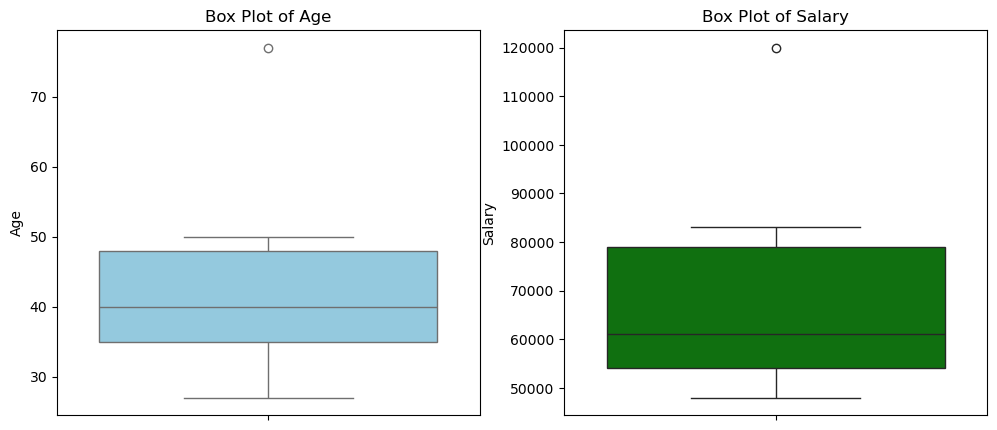

In [10]:
plt.figure(figsize=(12, 5))

# Box plot for Age
plt.subplot(1, 2, 1)
sns.boxplot(y=dataset['Age'], color='skyblue')
plt.title('Box Plot of Age')

# Box plot for Salary
plt.subplot(1, 2, 2)
sns.boxplot(y=dataset['Salary'], color='green')
plt.title('Box Plot of Salary')

plt.show()

## 3) Outlier Detection with IQR

The Interquartile Range method uses Q1 and Q3 to define a normal range. Values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are treated as outliers. This method is simple and robust for many tabular datasets.

In [11]:
def outlier_iqr(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    outlier = df[(df[col] < lb) | (df[col] > ub)]
    return lb, ub, outlier

In [12]:
lb,ub,outlier = outlier_iqr(dataset,"Age")

## 4) Imputer

`SimpleImputer` fills missing values instead of dropping rows. This preserves more data for training. A common strategy is `mean` for numeric columns.

In [19]:

from sklearn.impute import SimpleImputer
X= dataset.iloc[:,:-1].values
X


array([['France', 44.0, 72000.0],
       ['Spain', 27.0, 48000.0],
       ['Germany', 30.0, 54000.0],
       ['Spain', 38.0, 61000.0],
       ['Germany', 40.0, nan],
       ['France', 35.0, 58000.0],
       ['Spain', nan, 52000.0],
       ['France', 48.0, 79000.0],
       ['Germany', 50.0, 83000.0],
       ['Pakistan', 77.0, 120000.0]], dtype=object)

In [20]:

imputer = SimpleImputer()
X[ :,1:3] = imputer.fit_transform(X[ :,1:3])
X

array([['France', 44.0, 72000.0],
       ['Spain', 27.0, 48000.0],
       ['Germany', 30.0, 54000.0],
       ['Spain', 38.0, 61000.0],
       ['Germany', 40.0, 69666.66666666667],
       ['France', 35.0, 58000.0],
       ['Spain', 43.22222222222222, 52000.0],
       ['France', 48.0, 79000.0],
       ['Germany', 50.0, 83000.0],
       ['Pakistan', 77.0, 120000.0]], dtype=object)

## 5) Feature Scaling

Feature scaling standardizes numeric columns so each feature contributes on a comparable scale. `StandardScaler` transforms values using mean 0 and standard deviation 1.

In [23]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X[:, 1:3] = scaler.fit_transform(X[:, 1:3])
X

array([['France', 0.05873483671986508, 0.11605894828321828],
       ['Spain', -1.2250408801571866, -1.0776902340584555],
       ['Germany', -0.998492224237707, -0.7792529384730371],
       ['Spain', -0.3943624751190944, -0.4310760936233823],
       ['Germany', -0.2433300378394412, 2.220446049250313e-16],
       ['France', -0.6209111310385741, -0.5802947414160915],
       ['Spain', -8.881784197001253e-17, -0.8787320370015099],
       ['France', 0.3607997112791714, 0.46423579313287316],
       ['Germany', 0.5118321485588245, 0.6631939901898188],
       ['Pakistan', 2.5507700518341423, 2.5035573129665663]], dtype=object)